In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import joblib

In [2]:
data=pd.read_csv("job_salary_prediction_dataset.csv")
data.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
data.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.7 MB


In [5]:
data.describe()



,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [6]:
data['job_title'].value_counts()

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

In [7]:
data['remote_work'].value_counts()

remote_work
No        83621
Hybrid    83476
Yes       82903
Name: count, dtype: int64

In [8]:
def check_outliers(df):
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):  # ✅ correct check
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1

            lower_bound = q1 - (1.5 * iqr)
            upper_bound = q3 + (1.5 * iqr)

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

            print(f"Column: {col}")
            print(f"Outliers: {len(outliers)}")
    return df

check_outliers(data)

Column: experience_years
Outliers: 0
Column: skills_count
Outliers: 0
Column: certifications
Outliers: 0
Column: salary
Outliers: 2336


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [9]:

X=data[['certifications','skills_count','experience_years']]
y=data['salary']

In [10]:
def run_pipeline(
    X,
    y=None,
    model=None,
    scaler=None,
    test_size=0.2,
    random_state=42,
    task_type="regression",  # "regression", "classification", "clustering"
    return_model=False,
    elbow=False,
    k_range=(1, 10)   # 👈 start from 1 like standard elbow
):

    steps = []
    if scaler:
        steps.append(("scaler", scaler))
    steps.append(("model", model))

    pipeline = Pipeline(steps)

    # =========================
    # Supervised Learning
    # =========================
    if task_type in ["regression", "classification"]:
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        if task_type == "regression":
            score = mean_squared_error(y_test, y_pred)
            print(f"MSE: {score:.4f}")
        else:
            score = accuracy_score(y_test, y_pred)
            print(f"Accuracy: {score:.4f}")

    # =========================
    # Clustering
    # =========================
    elif task_type == "clustering":

        # Scaling
        if scaler:
            X_scaled = scaler.fit_transform(X)
        else:
            X_scaled = X

        # 🔥 Elbow Method (EXACT STYLE)
        if elbow:
            inertia = []
            K = range(k_range[0], k_range[1] + 1)

            for k in K:
                kmeans = KMeans(n_clusters=k, random_state=random_state)
                kmeans.fit(X_scaled)
                inertia.append(kmeans.inertia_)

            plt.figure()
            plt.plot(K, inertia, 'bo-')  # 👈 EXACT same as your example
            plt.xlabel('Number of clusters (k)')
            plt.ylabel('Inertia (SSE)')
            plt.title('Elbow Method for Optimal k')
            plt.show()

        # Fit final model
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        print(f"Silhouette Score: {score:.4f}")

    else:
        raise ValueError("task_type must be 'regression', 'classification', or 'clustering'")

    if return_model:
        return pipeline, score

    return score

In [11]:
xgpipline,score=run_pipeline(X,y,model=XGBRegressor(n_estimators=500,
        learning_rate=0.01,
        max_depth=3),scaler=None,task_type='regression',return_model=True)
xgpipline        

MSE: 1099033472.0000


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None


In [12]:
user_input=[[5,7,10]]

In [13]:
#Confidence Interval
salary = xgpipline.predict(user_input)[0]

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
y_pred_train = xgpipline.predict(X_train)
errors = y_train - y_pred_train

std = np.std(errors)

lower = salary - 1.96 * std
upper = salary + 1.96 * std

In [16]:
f"Expected salary: {salary:.0f} (range: {lower:.0f} - {upper:.0f})"

'Expected salary: 146134 (range: 81093 - 211175)'

In [17]:
#Percentile Ranking
percentile = (y < salary).mean() * 100
f"You earn more than: {percentile:.2f}% of people"

'You earn more than: 52.88% of people'

In [18]:
salary_bundle = {
    "model": xgpipline,
    "feature_cols": list(X.columns),
    "residual_std": float(std),
}
joblib.dump(salary_bundle, "save_models/salary_model.pkl")


['save_models/salary_model.pkl']

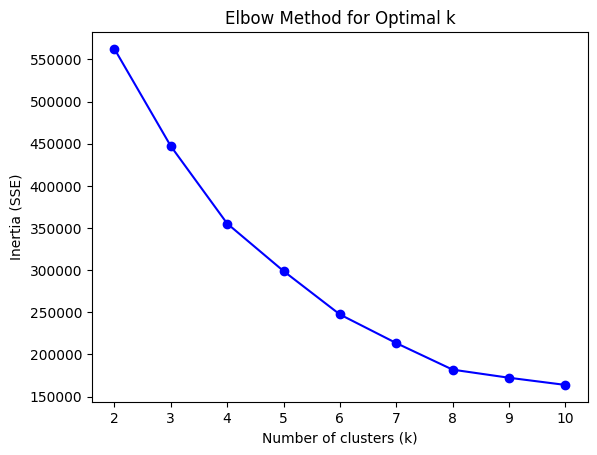

Silhouette Score: 0.2405


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final r

In [19]:
kmeanspipline,score=run_pipeline(
    X,
    model=KMeans(n_clusters=3, random_state=42),
    scaler=StandardScaler(),
    task_type="clustering",
    return_model=True,
    elbow=True,     
    k_range=(2, 10)
)
joblib.dump(
    {"pipeline": kmeanspipline, "feature_cols": list(X.columns), "n_clusters": 3},
    "save_models/kmeans_model.pkl",
)
kmeanspipline


In [20]:
joblib.dump({"pipeline": kmeanspipline, "feature_cols": list(X.columns), "n_clusters": 3}, "save_models/kmeans_model.pkl")


['save_models/kmeans_model.pkl']